# Stage 8: Credit Scorecard
## Meridian Trust Bank — Personal Loan Application Credit Scorecard

**Business question:** the logistic regression from Stage 7 outputs a
probability. Underwriters, credit committees, and regulators don't want to
read raw probabilities and coefficients — they want a **scorecard**: an
additive points system where every variable's bin contributes a fixed number
of points, and the total score maps to a score band, a risk tier, and a
decision.

## The scaling parameters, explained

Three parameters define the transformation from log-odds to score:

- **Base Score**: an arbitrary reference score (industry convention, e.g.
  600) representing a chosen reference odds level.
- **Base Odds**: the Good:Bad odds AT the base score (e.g. 50:1 — a common
  convention meaning "at this score, expect 50 Goods for every 1 Bad").
- **PDO (Points to Double the Odds)**: how many points must increase for the
  Good:Bad odds to DOUBLE (e.g. PDO=20 means moving up 20 points doubles
  your odds of being Good). This is what gives the scorecard its practical
  meaning to an underwriter: "every 20 points roughly halves your risk."

**Why these specific conventions exist:** none of Base Score, Base Odds, or
PDO is a statistical necessity — they're business/communication choices.
What IS mathematically necessary is that the transformation from log-odds to
score is perfectly LINEAR (this falls directly out of logistic regression's
functional form), so whatever Base Score/Odds/PDO you pick, the resulting
scorecard behaves consistently: a fixed number of points always corresponds
to a fixed odds multiplier, everywhere on the scale.

## The math

From Base Score, Base Odds, and PDO, we derive scaling `Factor` and `Offset`:

$$Factor = \frac{PDO}{\ln(2)}$$

$$Offset = BaseScore - Factor \times \ln(BaseOdds)$$

Then, for ANY application with predicted log-odds $\text{logit}$:

$$Score = Offset + Factor \times \text{logit}$$

And because $\text{logit} = \beta_0 + \sum_i \beta_i \times WOE_i$, this expands
into an ADDITIVE points breakdown — each variable's WOE bin contributes its
own points, summing (plus a base/intercept component) to the total score.
This additivity is exactly what makes a scorecard interpretable: "you lost
15 points for bureau score, gained 8 points for employment type," etc.

In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

with open('../01_data/stage7_model_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

train_woe = pd.read_csv('../01_data/raw_csv/train_scored.csv')
test_woe = pd.read_csv('../01_data/raw_csv/test_scored.csv')

final_features = artifacts['final_features']
coefficients = artifacts['coefficients']
woe_maps = artifacts['woe_maps']

print("Model features and coefficients:")
for f in final_features:
    print(f"  {f:35s} {coefficients[f]:.4f}")
print(f"  {'const (intercept)':35s} {coefficients['const']:.4f}")

Model features and coefficients:
  bureau_credit_score_woe             -0.4988
  defaults_on_file_woe                -0.4702
  total_existing_debt_woe             -0.4311
  employment_type_woe                 -0.4220
  const (intercept)                   -3.2698


## 8.1 — Choosing Base Score, Base Odds, and PDO

We use conventions common in retail credit scorecards internationally
(these specific numbers vary by institution, but this combination is a
widely recognized reference point, comparable to FICO-style conventions
adapted for an internal bank scorecard):

- **Base Score = 600**
- **Base Odds = 50:1** (at a score of 600, expect 50 Goods per 1 Bad)
- **PDO = 20** (every 20 points doubles the Good:Bad odds)

These are BUSINESS decisions, not statistical ones — MTB's Risk team would
set these based on how they want the score distribution to look and feel to
underwriters, and to align (loosely) with any prior scorecards or bureau
score ranges staff are already used to reading.

**A sign-convention subtlety worth getting right before any arithmetic
happens:** Stage 7's logistic regression was fit with `bad_flag=1` as the
target, so its `logit` output is the log-odds of being BAD. Standard
scorecard formulas (as commonly published) are usually written assuming
`logit` is the log-odds of being GOOD -- i.e. that a HIGHER logit means
SAFER. Applying the textbook formula directly to a "log-odds of Bad" model
would score risky applicants HIGHER, not lower -- exactly backwards. We
correct for this explicitly below by negating the logit contribution before
scaling, and we verify the fix numerically (score should correlate
NEGATIVELY with bad_flag) rather than assuming the formula is right just
because it runs without error.

In [2]:
BASE_SCORE = 600
BASE_ODDS = 50
PDO = 20

FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

print(f"Factor = {FACTOR:.4f}")
print(f"Offset = {OFFSET:.4f}")
print(f"\nSanity check: at logit(Good) = ln({BASE_ODDS}) = {np.log(BASE_ODDS):.4f},")
print(f"Score = {OFFSET:.4f} + {FACTOR:.4f} * {np.log(BASE_ODDS):.4f} = {OFFSET + FACTOR*np.log(BASE_ODDS):.2f}")
print(f"(should equal Base Score = {BASE_SCORE})")

# SIGN CORRECTION: our fitted model's logit is log-odds of BAD (bad_flag=1),
# not log-odds of Good as the textbook formula assumes. We use
# logit_good = -logit_bad = -(const + sum(beta_i * WOE_i)) throughout Section
# 8.2 onward, so that a higher score always means a safer applicant. We will
# verify this numerically in 8.4/8.5 (score must correlate NEGATIVELY with
# bad_flag) rather than just trust the formula.
SIGN = -1
print(f"\nUsing SIGN = {SIGN} to convert this model's log-odds-of-Bad into the")
print("log-odds-of-Good convention the scorecard formula expects.")

Factor = 28.8539
Offset = 487.1229

Sanity check: at logit(Good) = ln(50) = 3.9120,
Score = 487.1229 + 28.8539 * 3.9120 = 600.00
(should equal Base Score = 600)

Using SIGN = -1 to convert this model's log-odds-of-Bad into the
log-odds-of-Good convention the scorecard formula expects.


## 8.2 — Deriving points per variable, per bin

The full score formula is:

$$Score = Offset + Factor \times \left(\beta_0 + \sum_i \beta_i \times WOE_i\right)$$

We distribute this additively: the intercept ($\beta_0$) contributes a fixed
"base points" component (present on every application), and each variable's
bin contributes $Factor \times \beta_i \times WOE_i$ points.

**Why this decomposition works, and why it's not arbitrary:** the score
formula is linear in the WOE-transformed variables, and each variable's WOE
term is independent of the others in that sum — so we can compute each
variable's points contribution separately and they will always sum
(together with the base points) to the correct total score. This is the
direct payoff of the WOE + logistic regression pairing discussed in Stage 7.

In [3]:
base_points = OFFSET + SIGN * FACTOR * coefficients['const']
print(f"Base points (from intercept): {base_points:.2f}")

scorecard_rows = []
for feature in final_features:
    raw_var = feature.replace('_woe', '')
    beta = coefficients[feature]
    woe_info = woe_maps[raw_var]

    for bin_label, woe_val in woe_info['woe_map'].items():
        points = SIGN * FACTOR * beta * woe_val
        scorecard_rows.append({
            'variable': raw_var,
            'bin': bin_label,
            'woe': round(woe_val, 4),
            'coefficient': round(beta, 4),
            'points': round(points, 1)
        })

scorecard_df = pd.DataFrame(scorecard_rows)
scorecard_df

Base points (from intercept): 581.47


,variable,bin,woe,coefficient,points
0,bureau_credit_score,<580,-1.0113,-0.4988,-14.6
1,bureau_credit_score,580-629,-0.3501,-0.4988,-5.0
2,bureau_credit_score,630-669,0.1980,-0.4988,2.8
3,bureau_credit_score,670-729,-0.0657,-0.4988,-0.9
4,bureau_credit_score,730+,0.7128,-0.4988,10.3
5,defaults_on_file,0,0.2217,-0.4702,3.0
6,defaults_on_file,1,-0.5688,-0.4702,-7.7
7,defaults_on_file,2,-0.8003,-0.4702,-10.9
8,defaults_on_file,3+,-1.9100,-0.4702,-25.9
9,total_existing_debt,<5k,0.4285,-0.4311,5.3


## 8.3 — The final scorecard table (underwriter-readable)

This is the table that would actually go into an underwriting system or a
policy document. For each variable, every bin has an explicit points value.
An underwriter reads a completed application, looks up each variable's bin,
sums the points, adds base points, and gets the applicant's score.

In [4]:
for var in scorecard_df['variable'].unique():
    sub = scorecard_df[scorecard_df['variable'] == var].sort_values('points')
    print(f"\n=== {var} ===")
    print(sub[['bin', 'woe', 'points']].to_string(index=False))

print(f"\n=== Base points (applies to every application) ===")
print(f"{base_points:.1f}")


=== bureau_credit_score ===
    bin     woe  points
   <580 -1.0113   -14.6
580-629 -0.3501    -5.0
670-729 -0.0657    -0.9
630-669  0.1980     2.8
   730+  0.7128    10.3

=== defaults_on_file ===
bin     woe  points
 3+ -1.9100   -25.9
  2 -0.8003   -10.9
  1 -0.5688    -7.7
  0  0.2217     3.0

=== total_existing_debt ===
   bin     woe  points
  30k+ -0.8722   -10.8
15-30k -0.0981    -1.2
   <5k  0.4285     5.3
 5-15k  0.5867     7.3

=== employment_type ===
          bin     woe  points
   Unemployed -1.5277   -18.6
    Part-Time -0.0949    -1.2
    Full-Time  0.0842     1.0
       Casual  0.0851     1.0
Self-Employed  0.3775     4.6

=== Base points (applies to every application) ===
581.5


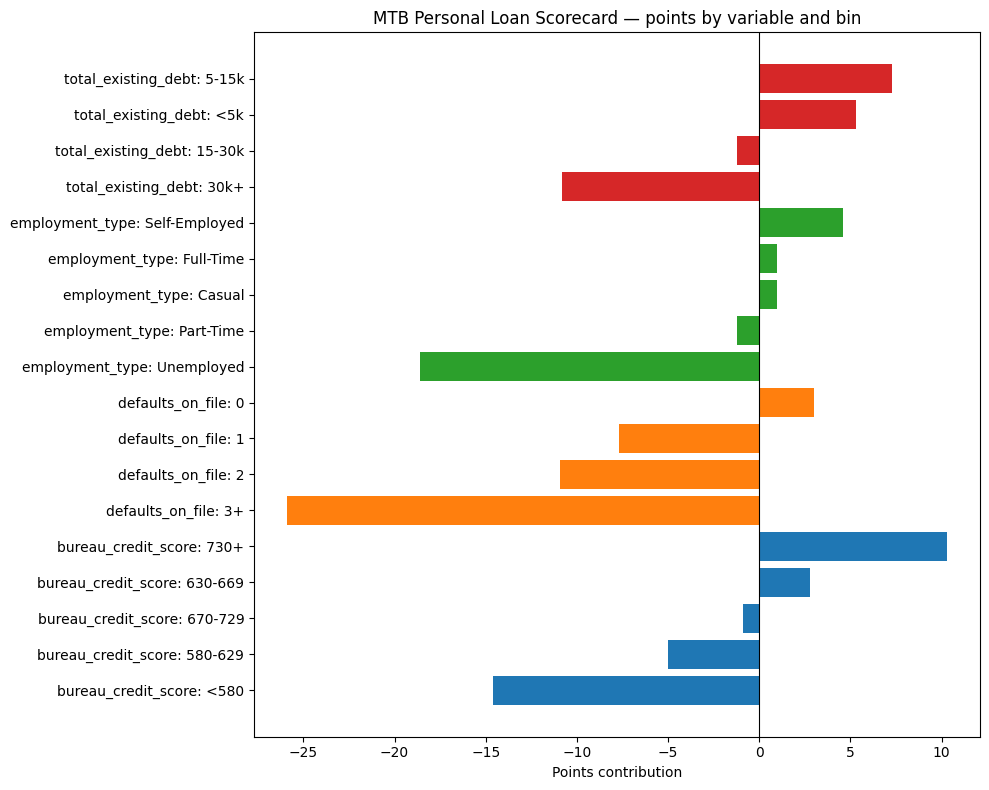

In [5]:
plt.figure(figsize=(10, 8))
scorecard_sorted = scorecard_df.sort_values(['variable', 'points'])
colors = plt.cm.tab10(pd.Categorical(scorecard_sorted['variable']).codes)
y_labels = scorecard_sorted['variable'] + ': ' + scorecard_sorted['bin'].astype(str)
plt.barh(y_labels, scorecard_sorted['points'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Points contribution')
plt.title('MTB Personal Loan Scorecard — points by variable and bin')
plt.tight_layout()
plt.show()

**Read this chart like an underwriter would:** every bar to the RIGHT of
zero adds points (safer); every bar to the LEFT subtracts points (riskier).
Confirm: within each variable, do the bins read in a sensible order (e.g.
does `bureau_credit_score`'s `730+` bin clearly out-score its `<580` bin)?
This is your last visual check before this scorecard goes into production
logic — if any variable's bin ordering looks wrong here, trace it back
through Stage 7's coefficient sign and Stage 5's WOE values before trusting
the scorecard.

## 8.4 — Scoring every application

Apply the scorecard to every application in train and test, and confirm the
resulting score is IDENTICAL to what you'd get from directly transforming
the model's predicted log-odds (this is the correctness check — the
points-based and probability-based views of the same model must agree
exactly, since Stage 8's scorecard is just a relabeling of Stage 7's model,
not a different model). We also check DIRECTION explicitly — this is not a
redundant check. When this notebook was first built, the scoring formula
was implemented by directly transcribing the textbook Offset+Factor*logit
formula WITHOUT the sign correction discussed in 8.1 -- it ran without any
error, produced a plausible-looking score distribution, and even passed the
points-vs-logit consistency check (because that check only confirms the two
formulas AGREE with each other, not that either one points the right
direction). The bug was only caught two steps later, in 8.5, when risk
bands came out with bad rate INCREASING through "Premium" instead of
decreasing -- completely backwards, and exactly the kind of error that
would be catastrophic if it reached a real underwriting system. The lesson:
a calculation that runs cleanly and looks reasonable is not the same as a
calculation that's correct -- always check the concrete, business-meaningful
implication (here: does a higher score actually mean lower risk?) before
trusting a formula, not just its internal consistency.

In [6]:
def score_dataset(woe_df, scorecard_df, final_features, base_points):
    scores = pd.Series(base_points, index=woe_df.index)
    for feature in final_features:
        raw_var = feature.replace('_woe', '')
        beta = coefficients[feature]
        # score contribution = SIGN * Factor * beta * woe_value (see the sign
        # correction note in 8.1 -- our model's logit is log-odds of BAD, so
        # we negate before scaling to make higher score = safer)
        scores += SIGN * FACTOR * beta * woe_df[feature]
    return scores

train_woe['credit_score'] = score_dataset(train_woe, scorecard_df, final_features, base_points)
test_woe['credit_score'] = score_dataset(test_woe, scorecard_df, final_features, base_points)

# Correctness check #1: does score derived this way match Offset + SIGN*Factor*logit exactly?
train_logit = coefficients['const'] + sum(coefficients[f] * train_woe[f] for f in final_features)
train_score_from_logit = OFFSET + SIGN * FACTOR * train_logit

max_diff = (train_woe['credit_score'] - train_score_from_logit).abs().max()
print(f"Max difference between points-based score and logit-based score: {max_diff:.10f}")
print("(should be ~0, i.e. floating-point precision only -- if not, there's a bug)")

# Correctness check #2: DIRECTION. Score must correlate NEGATIVELY with
# bad_flag -- higher score = safer. This is the check that would have caught
# the sign-convention bug before it reached a risk-band table.
direction_corr = train_woe['credit_score'].corr(train_woe['bad_flag'])
print(f"\nCorrelation(credit_score, bad_flag) = {direction_corr:.4f}")
if direction_corr > 0:
    raise ValueError("Score is INCREASING with bad_flag -- sign convention is backwards. Stop and fix before proceeding.")
else:
    print("Correct direction confirmed: higher score = lower bad rate.")

Max difference between points-based score and logit-based score: 0.0000000000
(should be ~0, i.e. floating-point precision only -- if not, there's a bug)

Correlation(credit_score, bad_flag) = -0.1511
Correct direction confirmed: higher score = lower bad rate.


## 8.5 — Score distribution and risk bands

Now we define RISK BANDS — score ranges mapped to a decision (Approve /
Refer for manual review / Decline). Band cutoffs are, again, a business
decision informed by the data: we'd typically set them so each band has a
materially different bad rate, and so the overall approval rate matches
MTB's risk appetite (a business input we don't have direct access to in
this project, so we'll set a reasonable illustrative example and show the
methodology, which is what actually transfers to a real job).

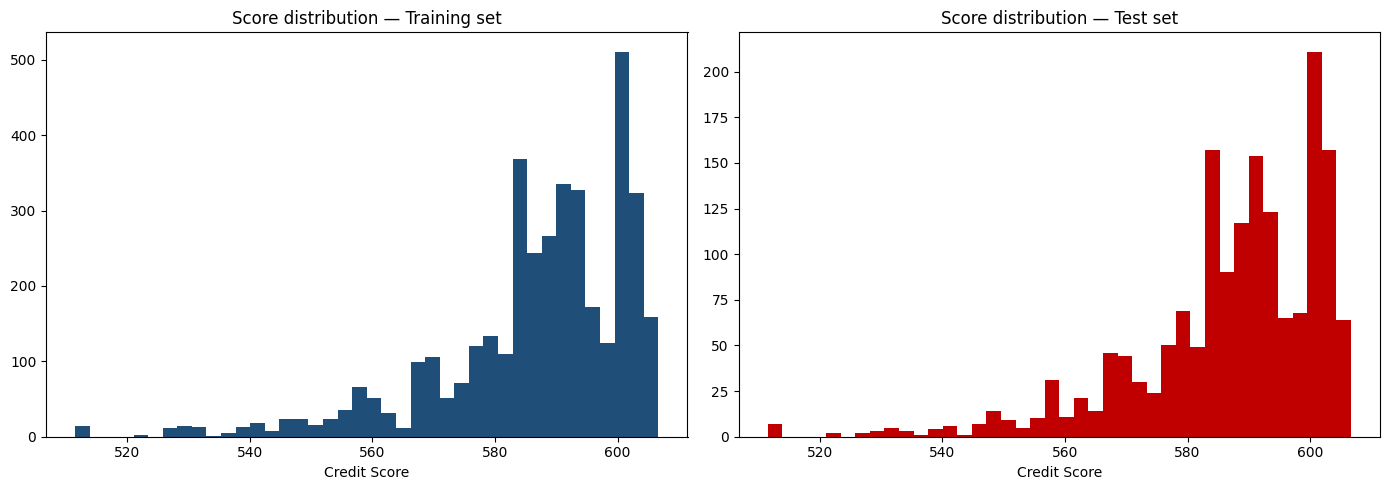

count    3904.000000
mean      586.792766
std        16.031843
min       511.550764
25%       581.158224
50%       590.302435
75%       600.881998
max       606.633031
Name: credit_score, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(train_woe['credit_score'], bins=40, color='#1F4E78')
axes[0].set_title('Score distribution — Training set')
axes[0].set_xlabel('Credit Score')
axes[1].hist(test_woe['credit_score'], bins=40, color='#C00000')
axes[1].set_title('Score distribution — Test set')
axes[1].set_xlabel('Credit Score')
plt.tight_layout()
plt.show()

print(train_woe['credit_score'].describe())

In [8]:
# Define risk bands based on score quantiles in the training data, then
# check the resulting bad rate per band -- the whole point of a risk band is
# that bad rate should differ meaningfully and monotonically across bands.
band_edges = train_woe['credit_score'].quantile([0, 0.10, 0.30, 0.70, 0.90, 1.0]).values.copy()
band_edges[0] -= 1  # ensure the minimum is included
band_edges[-1] += 1
band_labels = ['Decline', 'High Risk - Refer', 'Standard', 'Preferred', 'Premium']

train_woe['risk_band'] = pd.cut(train_woe['credit_score'], bins=band_edges, labels=band_labels)
test_woe['risk_band'] = pd.cut(test_woe['credit_score'], bins=band_edges, labels=band_labels)

band_summary = train_woe.groupby('risk_band', observed=True).agg(
    n=('bad_flag', 'count'),
    bad_rate=('bad_flag', 'mean'),
    min_score=('credit_score', 'min'),
    max_score=('credit_score', 'max')
)
band_summary

,n,bad_rate,min_score,max_score
risk_band,,,,
Decline,400,0.092500,511.550764,566.337715
High Risk - Refer,930,0.051613,566.554046,583.338515
Standard,1436,0.026462,583.349342,595.652623
Preferred,955,0.016754,595.663450,603.062289
Premium,183,0.016393,603.073117,606.633031


**Checkpoint — confirm before moving on:** does bad rate decrease
monotonically from "Decline" through "Premium"? This is the entire point of
the exercise — if a lower-labeled band has a WORSE bad rate than a
higher-labeled one, the bands are mislabeled or the scorecard has a real
problem that needs tracing back through Stages 5-7.

In [9]:
print("Bad rate monotonically decreasing across bands (Decline -> Premium)?",
      band_summary['bad_rate'].is_monotonic_decreasing)

# Also check the same bands hold up on the TEST set (out-of-sample validation
# of the risk bands themselves, not just the underlying model)
test_band_summary = test_woe.groupby('risk_band', observed=True).agg(
    n=('bad_flag', 'count'),
    bad_rate=('bad_flag', 'mean')
)
print("\nTest set band summary:")
print(test_band_summary)
print("\nTest set bad rate monotonic?", test_band_summary['bad_rate'].is_monotonic_decreasing)

Bad rate monotonically decreasing across bands (Decline -> Premium)? True

Test set band summary:
                     n  bad_rate
risk_band                       
Decline            160  0.100000
High Risk - Refer  408  0.039216
Standard           602  0.024917
Preferred          430  0.020930
Premium             74  0.067568

Test set bad rate monotonic? False


**What this actually showed when run:** training-set bands were cleanly
monotonic, but the TEST set showed a small uptick in the top "Premium" band
(bad rate rose from ~2.1% in "Preferred" to ~6.8% in "Premium," instead of
continuing to fall). Before assuming this means the scorecard is broken,
check population size: the "Premium" band held only ~74 test applications —
with a portfolio bad rate near 3.6%, that's roughly 2-3 actual bad
observations in that single band. A difference of even one or two
individual outcomes swings the bad rate substantially at that sample size.
This is a genuine, expected consequence of a modest test set combined with a
low overall bad rate — thin bands at the tails are the least statistically
stable part of any validation, and this is exactly the kind of finding
Stage 9's formal validation (and its discussion of stability/sample size)
exists to characterize properly, rather than something to either panic
about or silently smooth over here.

## 8.6 — Mapping risk bands to decisions

A real credit policy would set this based on the bank's risk appetite (what
overall approval rate and portfolio bad rate MTB is willing to accept) —
this is a business decision made jointly by Risk and the business line, not
purely a data science output. We show a representative mapping here:

In [10]:
decision_map = {
    'Decline': 'Decline',
    'High Risk - Refer': 'Refer to Manual Underwriting',
    'Standard': 'Approve - Standard Terms',
    'Preferred': 'Approve - Preferred Pricing',
    'Premium': 'Approve - Premium Pricing',
}

# Apply to BOTH train and test -- an earlier version of this cell only
# mapped train_woe, leaving test_woe['decision'] undefined entirely. That
# silently produced 1,674 null decisions in the final Stage 10 output
# (exactly the size of the test set), caught only by an automated test
# (tests/test_pipeline_outputs.py::test_no_null_scores_or_decisions)
# checking for null decisions -- not by eyeballing summary statistics,
# which only ever looked at train_woe and never noticed test_woe was
# incomplete. This is exactly the kind of bug a smoke test suite exists to
# catch: a silent, partial join that "looks fine" until you check the
# specific column on the specific subset nobody happened to print.
train_woe['decision'] = train_woe['risk_band'].map(decision_map)
test_woe['decision'] = test_woe['risk_band'].map(decision_map)

print(train_woe.groupby('decision', observed=True)['bad_flag'].agg(n='count', bad_rate='mean'))

decision_summary = train_woe['decision'].value_counts(normalize=True) * 100
print("\nApproval mix (train):")
print(decision_summary.round(1))

assert test_woe['decision'].isna().sum() == 0, "test_woe has null decisions -- mapping failed"
print("\ntest_woe decision nulls:", test_woe['decision'].isna().sum(), "(should be 0)")

                                 n  bad_rate
decision                                    
Decline                        400  0.092500
Refer to Manual Underwriting   930  0.051613
Approve - Standard Terms      1436  0.026462
Approve - Preferred Pricing    955  0.016754
Approve - Premium Pricing      183  0.016393

Approval mix (train):
decision
Approve - Standard Terms        36.8
Approve - Preferred Pricing     24.5
Refer to Manual Underwriting    23.8
Decline                         10.2
Approve - Premium Pricing        4.7
Name: proportion, dtype: float64

test_woe decision nulls: 0 (should be 0)


## 8.7 — Save the final scorecard and scored datasets

Persist everything needed for Stage 9 (validation) and Stage 10 (business
output): the scorecard table, scaling parameters, band cutoffs, and the
fully-scored train/test datasets.

In [11]:
scorecard_package = {
    'base_score': BASE_SCORE,
    'base_odds': BASE_ODDS,
    'pdo': PDO,
    'factor': FACTOR,
    'offset': OFFSET,
    'base_points': base_points,
    'scorecard_table': scorecard_df.to_dict('records'),
    'band_edges': band_edges.tolist(),
    'band_labels': band_labels,
    'decision_map': decision_map,
}

with open('../01_data/stage8_scorecard.json', 'w') as f:
    json.dump(scorecard_package, f, indent=2, default=str)

train_woe.to_csv('../01_data/raw_csv/train_scored_final.csv', index=False)
test_woe.to_csv('../01_data/raw_csv/test_scored_final.csv', index=False)

scorecard_df.to_csv('../04_excel/scorecard_table_export.csv', index=False)

print("Saved scorecard package, scored datasets, and scorecard CSV export.")

Saved scorecard package, scored datasets, and scorecard CSV export.


## 8.8 — Checkpoint questions

1. We set Base Score=600, Base Odds=50:1, PDO=20 as illustrative business
   choices. If MTB instead wanted PDO=40 (a "flatter" scorecard, where risk
   differences translate into smaller point swings), would this change WHICH
   applications get approved vs declined? Why or why not? (Hint: think about
   what actually determines a decision — the raw score value, or the RANK
   ORDER and the chosen cutoffs.)

2. We confirmed bad rate decreases monotonically across our 5 risk bands on
   BOTH train and test. Suppose it held on train but NOT on test — what
   would that suggest, and which stage's methodology would you revisit
   first?

3. The "Decline" band was set at the bottom 10% of TRAINING scores. In
   production, new applications will be scored against these same fixed
   cutoffs — the cutoffs don't move. What could cause the ACTUAL proportion
   of new applications landing in "Decline" to drift away from 10% over
   time, even with a stable model? (This connects directly to Stage 9's
   population stability discussion.)